# [LAB-09] 선형회귀ㅣ07-[PBT] 선형회귀 파이프라인(실습코드).ipynb

### 1. 라이브러리 참조 

In [1]:
from jussam import load_data
from helpers import *
from IPython.display import display, Markdown


📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


## #01. 준비작업 

### 2. 품질 점검 완료 데이터셋 가져오기 

In [2]:
origin = load_data("diamonds_qtcheck")
num_desc = load_data("diamonds_numerical_summary")
cat_desc = load_data("diamonds_categorical_summary")

📚 다이아몬드 데이터셋의 품질 검사 완료 버전 (출처: 자체 정제)

    field    description
--  -------  -------------------------------------------------------------------
 0  price    다이아몬드 가격 (USD, $326 ~ $18,823)
 1  carat    중량 (0.2~5.01)
 2  cut      컷 품질 (Fair, Good, Very Good, Premium, Ideal)
 3  color    색상 등급 - J (worst) to D (best)
 4  clarity  투명도 등급 (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best))
 5  x        길이 mm (0~10.74)
 6  y        너비 mm (0--58.9)
 7  z        두께 mm (0--31.8)
 8  depth    비율 정보 = z / mean(x, y) = 2 * z / (x + y) (43--79)
 9  table    다이아몬드의 가장 넓은 지점에 비해 상단(테이블)의 너비 (43--95)

📚 다이아몬드 데이터셋의 연속형 변수에 대한 기술 통계량 (출처: 자체 작업)
📚 다이아몬드 데이터셋의 범주형 변수에 대한 기술 통계량 (출처: 자체 작업)


### 3.  EDA 결과 반영 

In [3]:
# 제외 대상 컬럼 제거 
df_eda = origin.drop(columns=["depth"])

# 기술 통계량에서 제외 대상 컬럼 제거 
num_desc_eda = num_desc.drop(index="depth")

# 범주형은 변경사항이 없으므로 그대로 복사
cat_desc_eda = cat_desc.copy()

### 4. 타입 변환 (명목형 확정)

In [4]:
df = my_qtcheck.set_type(df_eda, as_category=cat_desc.columns)

<class 'pandas.DataFrame'>
RangeIndex: 53794 entries, 0 to 53793
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   price    53794 non-null  int64   
 1   carat    53794 non-null  float64 
 2   cut      53794 non-null  category
 3   color    53794 non-null  category
 4   clarity  53794 non-null  category
 5   x        53794 non-null  float64 
 6   y        53794 non-null  float64 
 7   z        53794 non-null  float64 
 8   table    53794 non-null  float64 
dtypes: category(3), float64(5), int64(1)
memory usage: 2.6 MB


### 5. 변수 유형 분류 

In [5]:
# 종속변수 
target = "price"    
# 종속변수 연속형 여부 
target_is_continuous = True

# 명목형 변수 
nominal_cols = my_qtcheck.get_categorical_column_names(df)
# 연속형 변수 
continuous_cols = my_qtcheck.get_number_column_names(df)

if target_is_continuous:
    # 연속형 변수 이름에서 종속변수 항목 제거 
    continuous_cols.remove(target)
else:
    # 명목형 변수 이름에서 종속변수 항목 제거 
    nominal_cols.remove(target)

print("종속변수: ", target)
print("종속변수 유형: " +("연속형" if target_is_continuous else "명목형"))
print("명목형 : ", nominal_cols)
print("연속형 : ", continuous_cols)

종속변수:  price
종속변수 유형: 연속형
명목형 :  ['cut', 'color', 'clarity']
연속형 :  ['carat', 'x', 'y', 'z', 'table']


### 6. 컬럼 의미를 정리한 딕셔너리 

In [6]:
column_means = {
    "price" : "다이아몬드 가격 (USD)", 
    "catat" : "중량", 
    "cut" : "컷팅 등급", # Fair, Good, Very Good, Premium, Ideal 
    "color" : "색상 등급", # J (worst) to D (best)
    "clarity" : "투명도 등급", #(I1 (worst), SI2, SI1, VS2, VS1, VVS2, IF(best))
    "x" : "길이(mm)", 
    "y" : "너비(mm)", 
    "z" : "두께(mm)",
    "table" : "테이블 너비"
}

### 7. 서열척도 적용( 필요에 따라 수행 )


In [7]:
# 서열척도를 적용할 변수와 순서를 정의한다. (낮은 등급 -> 높은 등급)
# -> 도메인 지식이 필요한 부분이므로 #01(준비작업) 에서만 수정한다. 
# 서열척도 대상이 없는 데이터셋이라면 제외하면 된다. 
ordinal_map = {
    "cut" : ["Fair", "Good", "Very Good", "Premium", "Ideal"],
    "color" : ["J", "I", "H", "G", "F", "E", "D"], 
    "clarity" : ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"], 
}

# 정의된 내용에 따라 순서를 재지정 한다. 
# -> 데이터셋에 없는 컬럼은 건너 뛰므로 다른 데이터셋에서도 오류가 나지 않는다. 
for col, order in ordinal_map.items():
    if col in df.columns:
        df[col] = df[col].cat.reorder_categories(order, ordered=True)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53794 entries, 0 to 53793
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   price    53794 non-null  int64   
 1   carat    53794 non-null  float64 
 2   cut      53794 non-null  category
 3   color    53794 non-null  category
 4   clarity  53794 non-null  category
 5   x        53794 non-null  float64 
 6   y        53794 non-null  float64 
 7   z        53794 non-null  float64 
 8   table    53794 non-null  float64 
dtypes: category(3), float64(5), int64(1)
memory usage: 2.6 MB


## #02. 선형회귀 파이프라인 

### 1. 전처리 체크포인트 정의 
전처리 단계를 하나씩 누적한 체크포인트 (아래로 갈수록 전처리가 하나 더 붙는다)
labelign, encode는 기본값이 True 이므로 적지 않는다. 

In [8]:
checkpoints = {
    "0_기준선" : dict(), 
    "1_로그변환" : dict(log=True), 
    "2_이상치대체" : dict(log=True, outlier=True),
    "3_공선성제거" : dict(log=True, outlier=True, vif=True), 
    "4_스케일링" : dict(log=True, outlier=True, vif=True, scale=True), 
}

### 2. 더미변수의 기준 확인 
labeling은 명목형 값을 알파벳 순서로 0부터 매긴다.\
이어지는 'encode'(더미 인코딩)가 이 정수를 컬럼명에 사용하므로,\
회귀계수를 해석하려면 매핑을 알아야 한다.\
    예) 'cut_2'는 'cut=Ideal'을 의미한다\
drop_first = True 로 0번 범주가 기준이 되어 빠진다. 

In [9]:
# 라벨 매핑만 확인하는 용도 (반환값은 사용하지 않는다)
_ = my_prep.labeling(df, columns=nominal_cols)

cut (1종) : Fair=0
cut (2종) : Fair=0, Good=1
cut (3종) : Fair=0, Good=1, Ideal=2
cut (4종) : Fair=0, Good=1, Ideal=2, Premium=3
cut (5종) : Fair=0, Good=1, Ideal=2, Premium=3, Very Good=4
color (1종) : D=0
color (2종) : D=0, E=1
color (3종) : D=0, E=1, F=2
color (4종) : D=0, E=1, F=2, G=3
color (5종) : D=0, E=1, F=2, G=3, H=4
color (6종) : D=0, E=1, F=2, G=3, H=4, I=5
color (7종) : D=0, E=1, F=2, G=3, H=4, I=5, J=6
clarity (1종) : I1=0
clarity (2종) : I1=0, IF=1
clarity (3종) : I1=0, IF=1, SI1=2
clarity (4종) : I1=0, IF=1, SI1=2, SI2=3
clarity (5종) : I1=0, IF=1, SI1=2, SI2=3, VS1=4
clarity (6종) : I1=0, IF=1, SI1=2, SI2=3, VS1=4, VS2=5
clarity (7종) : I1=0, IF=1, SI1=2, SI2=3, VS1=4, VS2=5, VVS1=6
clarity (8종) : I1=0, IF=1, SI1=2, SI2=3, VS1=4, VS2=5, VVS1=6, VVS2=7


### 3. 체크포인트별 모델 적합 
fit_pipeline은 전처리 부터 모델 적합까지 한번에 수행하고\
계수 해석에 필요한 변환 정보를 결과 객체에 붙여 돌려준다.

backward=True(기본값)이므로 \
유의하지 않은 독립변수는 후진소거법으로 하나씩 제거된다. 

In [10]:
fits = {}

for name in checkpoints:
    print(f"\n > --- {name} --- ")

    # 전처리 + 모델 적합을 한 번에 수행한다.
    # -> name 을 지정해두면 compare_models 의 결과표에 그대로 사용된다. 
    fits[name] = my_ols.fit_pipeline(df, target, 
                                     nominal_cols=nominal_cols, name=name, verbose=False, 
                                     **checkpoints[name])


 > --- 0_기준선 --- 

유의하지 않은 독립변수 제거 → y (p = 0.7865)
유의하지 않은 독립변수 제거 → z (p = 0.4474)

 > --- 1_로그변환 --- 

유의하지 않은 독립변수 제거 → table (p = 0.7514)

 > --- 2_이상치대체 --- 

유의하지 않은 독립변수 제거 → table (p = 0.5136)

 > --- 3_공선성제거 --- 

완료! 남은변수 : ['table', 'z']
최대 VIF = 1.03


 > --- 4_스케일링 --- 

완료! 남은변수 : ['table', 'z']
최대 VIF = 1.03



### 4. 성능비교와 최종모델 선택 
종속변수에 로그가 적용된 모델은 예측값을 원본 척도(달러)로 되돌려 \
RMSE, MAE, R^2 (원본척도)를 계산한다. 
    척도가 다른 지표(R2(모델척도), AIC, BIC)는 체크포인트 간 비교에 쓸 수 없다. \

1위와의 격차가 5% 이내면 근소 격차 그룹으로 묶어 변수가 더 적은(간명한)모델을 우선한다. 

In [11]:
# 성능표를 출력하고 가장 좋은 모델을 반환받는다. 
final_fit = my_ols.compare_models(fits)

print("최종모델: ", final_fit.name_)
print("독립변수: ", int(final_fit.df_model), "개")

,변수수,R2(모델척도),Adj.R2,AIC,BIC,R2(원본척도),RMSE,MAE,Gap(%)
모델,,,,,,,,,
2_이상치대체,21,0.983,0.983,-64286.219,-64090.575,0.957,831.952,406.251,0.000
1_로그변환,21,0.983,0.983,-64194.658,-63999.014,0.957,832.090,405.550,0.020
3_공선성제거,19,0.968,0.968,-30419.977,-30242.119,0.924,1096.543,475.759,31.800
4_스케일링,19,0.968,0.968,-30419.977,-30242.119,0.924,1096.543,475.759,31.800
0_기준선,20,0.919,0.919,909186.897,909373.649,0.919,1131.507,743.546,36.010


최종모델:  2_이상치대체
독립변수:  21 개


# 7-3 도메인 지식 적용 모델링 

## #03. 도메인 지식 반영 모델 전처리 

### 1. 데이터 전처리 

In [12]:
df2 = df.drop(columns=["x", "y", "z"])
df2.head()

,price,carat,cut,color,clarity,table
0,326,0.230,Ideal,E,SI2,55.000
1,326,0.210,Premium,E,SI1,61.000
2,327,0.230,Good,E,VS1,65.000
3,334,0.290,Premium,I,VS2,58.000
4,335,0.310,Good,J,SI2,58.000


### 2. 도메인 지식 전처리 버전에 대한 체크포인트 정의 

In [13]:
# 도메인 지식을 반영한 데이터(df2)에 적용할 체크포인트 
# -> 앞의 checkpoints와 전처리 조합을 동일하게 맞춘다
domain_checkpoints = {
    "5_도메인_기준선" : dict(),
    "6_도메인_로그변환" : dict(log=True), 
    "7_도메인_이상치대체" :dict(log=True, outlier=True), 
    "8_도메인_공선성제거": dict(log=True, outlier=True, vif=True), 
}

### 3. 모델 적합 

In [14]:
for name in domain_checkpoints:
    print(f"\n > --- {name} ---")

    # 데이터만 df2로 바꾸고 나머지는 동일하게 적합한다.
    # -> fits 에 누적하므로 앞의 5개 모델과 함께 비교된다. 
    fits[name] = my_ols.fit_pipeline(df2, target, 
                                     nominal_cols=nominal_cols, name=name, verbose=False,
                                     **domain_checkpoints[name])

print("\n 누적된 모델: ", len(fits), "개")


 > --- 5_도메인_기준선 ---


 > --- 6_도메인_로그변환 ---

유의하지 않은 독립변수 제거 → table (p = 0.9194)

 > --- 7_도메인_이상치대체 ---

유의하지 않은 독립변수 제거 → table (p = 0.9575)

 > --- 8_도메인_공선성제거 ---

완료! 남은변수 : ['carat', 'table']
최대 VIF = 1.04

유의하지 않은 독립변수 제거 → table (p = 0.9575)

 누적된 모델:  9 개


### 4. 전체 모델 성능 비교 

In [15]:
# 9개 모델을 한번에 비교한다
final_fit = my_ols.compare_models(fits)

print("최종 모델: ", final_fit.name_)
print("독립변수 : ", int(final_fit.df_model), "개")

,변수수,R2(모델척도),Adj.R2,AIC,BIC,R2(원본척도),RMSE,MAE,Gap(%)
모델,,,,,,,,,
7_도메인_이상치대체,18,0.983,0.983,-63903.108,-63734.143,0.960,796.879,402.916,0.000
8_도메인_공선성제거,18,0.983,0.983,-63903.108,-63734.143,0.960,796.879,402.916,0.000
6_도메인_로그변환,18,0.983,0.983,-63887.676,-63718.710,0.960,798.871,403.074,0.250
2_이상치대체,21,0.983,0.983,-64286.219,-64090.575,0.957,831.952,406.251,4.400
1_로그변환,21,0.983,0.983,-64194.658,-63999.014,0.957,832.090,405.550,4.420
3_공선성제거,19,0.968,0.968,-30419.977,-30242.119,0.924,1096.543,475.759,37.600
4_스케일링,19,0.968,0.968,-30419.977,-30242.119,0.924,1096.543,475.759,37.600
0_기준선,20,0.919,0.919,909186.897,909373.649,0.919,1131.507,743.546,41.990
5_도메인_기준선,19,0.916,0.916,911471.617,911649.475,0.916,1155.814,803.132,45.040


최종 모델:  7_도메인_이상치대체
독립변수 :  18 개


## #04. 최종 채택 모델에 대한 결과 보고 

### 1. 결과보고, 가정확인 일괄처리 (소스코드+결과확인1 - 모형 적합도)

## 최종모델: 7_도메인_이상치대체

### 성능보고

#### 1) 모형 적합도

**Note. n = 53794. F(18, 53775) = 169374.3, p < 0.001, R² = 0.983, Adj.R² = 0.983, Durbin-Watson = 1.253**

price를 종속변수로, carat, cut_1, cut_2, cut_3, cut_4, color_1, color_2, color_3, color_4, color_5, color_6, clarity_1, clarity_2, clarity_3, clarity_4, clarity_5, clarity_6, clarity_7(을)를 독립변수로한 다중선형회귀분석 결과, 모형은 통계적으로 유의하였다.

> F(18, 53775) = 169374.3, p < 0.001, R² = 0.983.

즉, carat, cut_1, cut_2, cut_3, cut_4, color_1, color_2, color_3, color_4, color_5, color_6, clarity_1, clarity_2, clarity_3, clarity_4, clarity_5, clarity_6, clarity_7는 price의 약 98.27%를 설명하는 것으로 나타났다.

#### 2) 회귀계수 보고표

,종속변수,독립변수,B,표준오차,표준오차(HC3),베타,t,t(HC3),유의확률,유의확률(HC3),공차,VIF
0,price,carat,1.884,0.001,0.001,1.086,1669.480,1452.680,0.000,0.000,0.762,1.312
1,price,clarity_5,0.741,0.005,0.009,0.306,143.216,86.484,0.000,0.000,0.071,14.172
2,price,clarity_4,0.811,0.005,0.009,0.287,154.440,94.256,0.000,0.000,0.093,10.697
3,price,clarity_7,0.946,0.005,0.009,0.272,174.772,107.779,0.000,0.000,0.133,7.524
4,price,clarity_6,1.018,0.006,0.009,0.252,182.710,114.560,0.000,0.000,0.169,5.912
5,price,clarity_2,0.592,0.005,0.009,0.250,115.063,69.201,0.000,0.000,0.068,14.647
6,price,clarity_1,1.113,0.006,0.009,0.196,184.636,119.041,0.000,0.000,0.285,3.510
7,price,clarity_3,0.427,0.005,0.009,0.158,82.580,49.577,0.000,0.000,0.088,11.394
8,price,color_6,-0.511,0.003,0.003,-0.112,-166.369,-154.951,0.000,0.000,0.712,1.405
9,price,color_5,-0.373,0.002,0.003,-0.110,-149.555,-142.317,0.000,0.000,0.591,1.691


#### 3) 영향력 순위 시각화 (표준화 계수 베타)

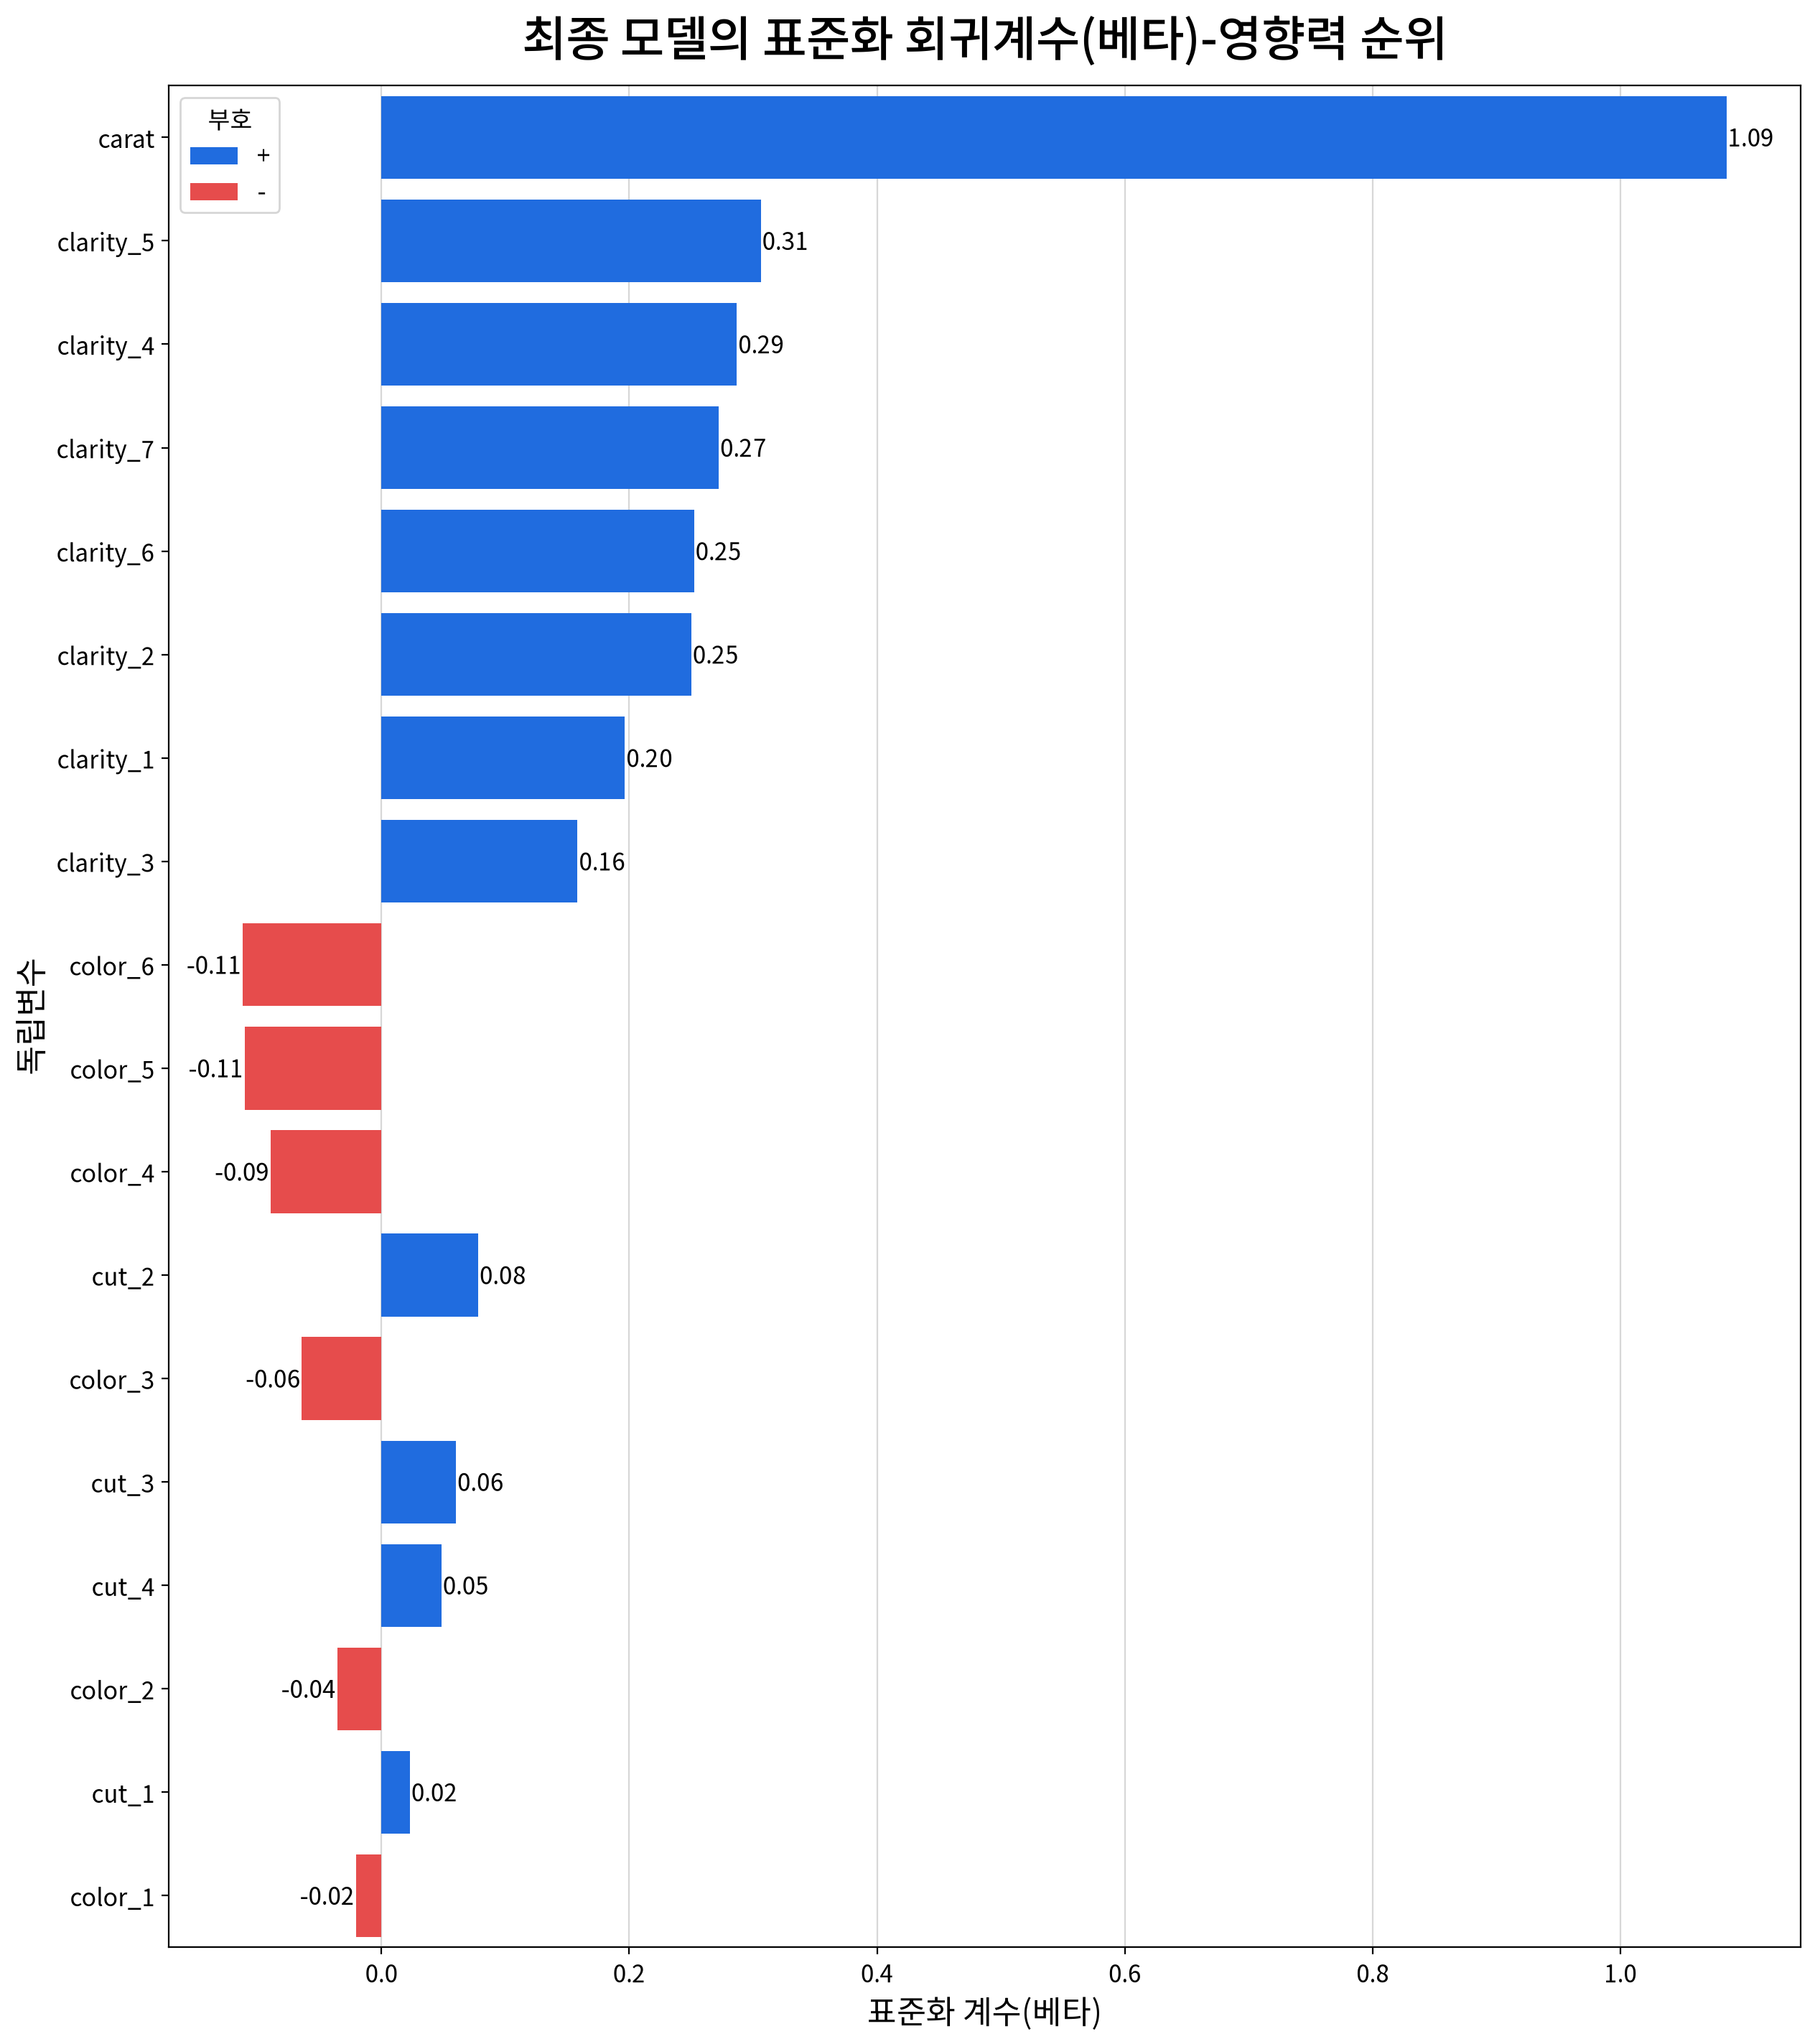

#### 4) 회귀계수 해석 문장

- **carat**의 회귀계수는 **B = 1.88**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 1452.68**, **p < .001**)      
즉, carat가 **1 증가**할 때 price는 평균적으로 **1.88 증가**하는 것으로 해석된다.
- **cut_1**의 회귀계수는 **B = 0.08**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 17.15**, **p < .001**)      
즉, cut_1가 **1 증가**할 때 price는 평균적으로 **0.08 증가**하는 것으로 해석된다.
- **cut_2**의 회귀계수는 **B = 0.16**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 36.2**, **p < .001**)      
즉, cut_2가 **1 증가**할 때 price는 평균적으로 **0.16 증가**하는 것으로 해석된다.
- **cut_3**의 회귀계수는 **B = 0.14**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 31.09**, **p < .001**)      
즉, cut_3가 **1 증가**할 때 price는 평균적으로 **0.14 증가**하는 것으로 해석된다.
- **cut_4**의 회귀계수는 **B = 0.12**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 26.18**, **p < .001**)      
즉, cut_4가 **1 증가**할 때 price는 평균적으로 **0.12 증가**하는 것으로 해석된다.
- **color_1**의 회귀계수는 **B = -0.05**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = -24.01**, **p < .001**)      
즉, color_1가 **1 증가**할 때 price는 평균적으로 **0.05 감소**하는 것으로 해석된다.
- **color_2**의 회귀계수는 **B = -0.09**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = -41.22**, **p < .001**)      
즉, color_2가 **1 증가**할 때 price는 평균적으로 **0.09 감소**하는 것으로 해석된다.
- **color_3**의 회귀계수는 **B = -0.16**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = -71.62**, **p < .001**)      
즉, color_3가 **1 증가**할 때 price는 평균적으로 **0.16 감소**하는 것으로 해석된다.
- **color_4**의 회귀계수는 **B = -0.25**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = -107.31**, **p < .001**)      
즉, color_4가 **1 증가**할 때 price는 평균적으로 **0.25 감소**하는 것으로 해석된다.
- **color_5**의 회귀계수는 **B = -0.37**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = -142.32**, **p < .001**)      
즉, color_5가 **1 증가**할 때 price는 평균적으로 **0.37 감소**하는 것으로 해석된다.
- **color_6**의 회귀계수는 **B = -0.51**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = -154.95**, **p < .001**)      
즉, color_6가 **1 증가**할 때 price는 평균적으로 **0.51 감소**하는 것으로 해석된다.
- **clarity_1**의 회귀계수는 **B = 1.11**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 119.04**, **p < .001**)      
즉, clarity_1가 **1 증가**할 때 price는 평균적으로 **1.11 증가**하는 것으로 해석된다.
- **clarity_2**의 회귀계수는 **B = 0.59**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 69.2**, **p < .001**)      
즉, clarity_2가 **1 증가**할 때 price는 평균적으로 **0.59 증가**하는 것으로 해석된다.
- **clarity_3**의 회귀계수는 **B = 0.43**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 49.58**, **p < .001**)      
즉, clarity_3가 **1 증가**할 때 price는 평균적으로 **0.43 증가**하는 것으로 해석된다.
- **clarity_4**의 회귀계수는 **B = 0.81**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 94.26**, **p < .001**)      
즉, clarity_4가 **1 증가**할 때 price는 평균적으로 **0.81 증가**하는 것으로 해석된다.
- **clarity_5**의 회귀계수는 **B = 0.74**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 86.48**, **p < .001**)      
즉, clarity_5가 **1 증가**할 때 price는 평균적으로 **0.74 증가**하는 것으로 해석된다.
- **clarity_6**의 회귀계수는 **B = 1.02**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 114.56**, **p < .001**)      
즉, clarity_6가 **1 증가**할 때 price는 평균적으로 **1.02 증가**하는 것으로 해석된다.
- **clarity_7**의 회귀계수는 **B = 0.95**으로 나타났으며, 이는 **price**에 유의한 요인임을 의미한다. (**t(53775) = 107.78**, **p < .001**)      
즉, clarity_7가 **1 증가**할 때 price는 평균적으로 **0.95 증가**하는 것으로 해석된다.

> ※ 위 **t**와 **유의확률**은 등분산 가정이 충족되지 않은 경우를 대비해 **HC3 로버스트 표준오차**로 계산한 값이다.     
회귀계수(B)와 효과 크기 해석은 일반 OLS와 동일하며,     
표준오차만 이분산에 강건하게 보정되어 유의성 판정이 달라질 수 있다.

---

### > 회귀모형 가정 검정

#### 1) 선형성 검정

,statistic,p-value,linearity,result
Ramsey RESET,923.615,0.000,False,대립가설 채택 -> 선형성 위배 (곡선 관계 존재)


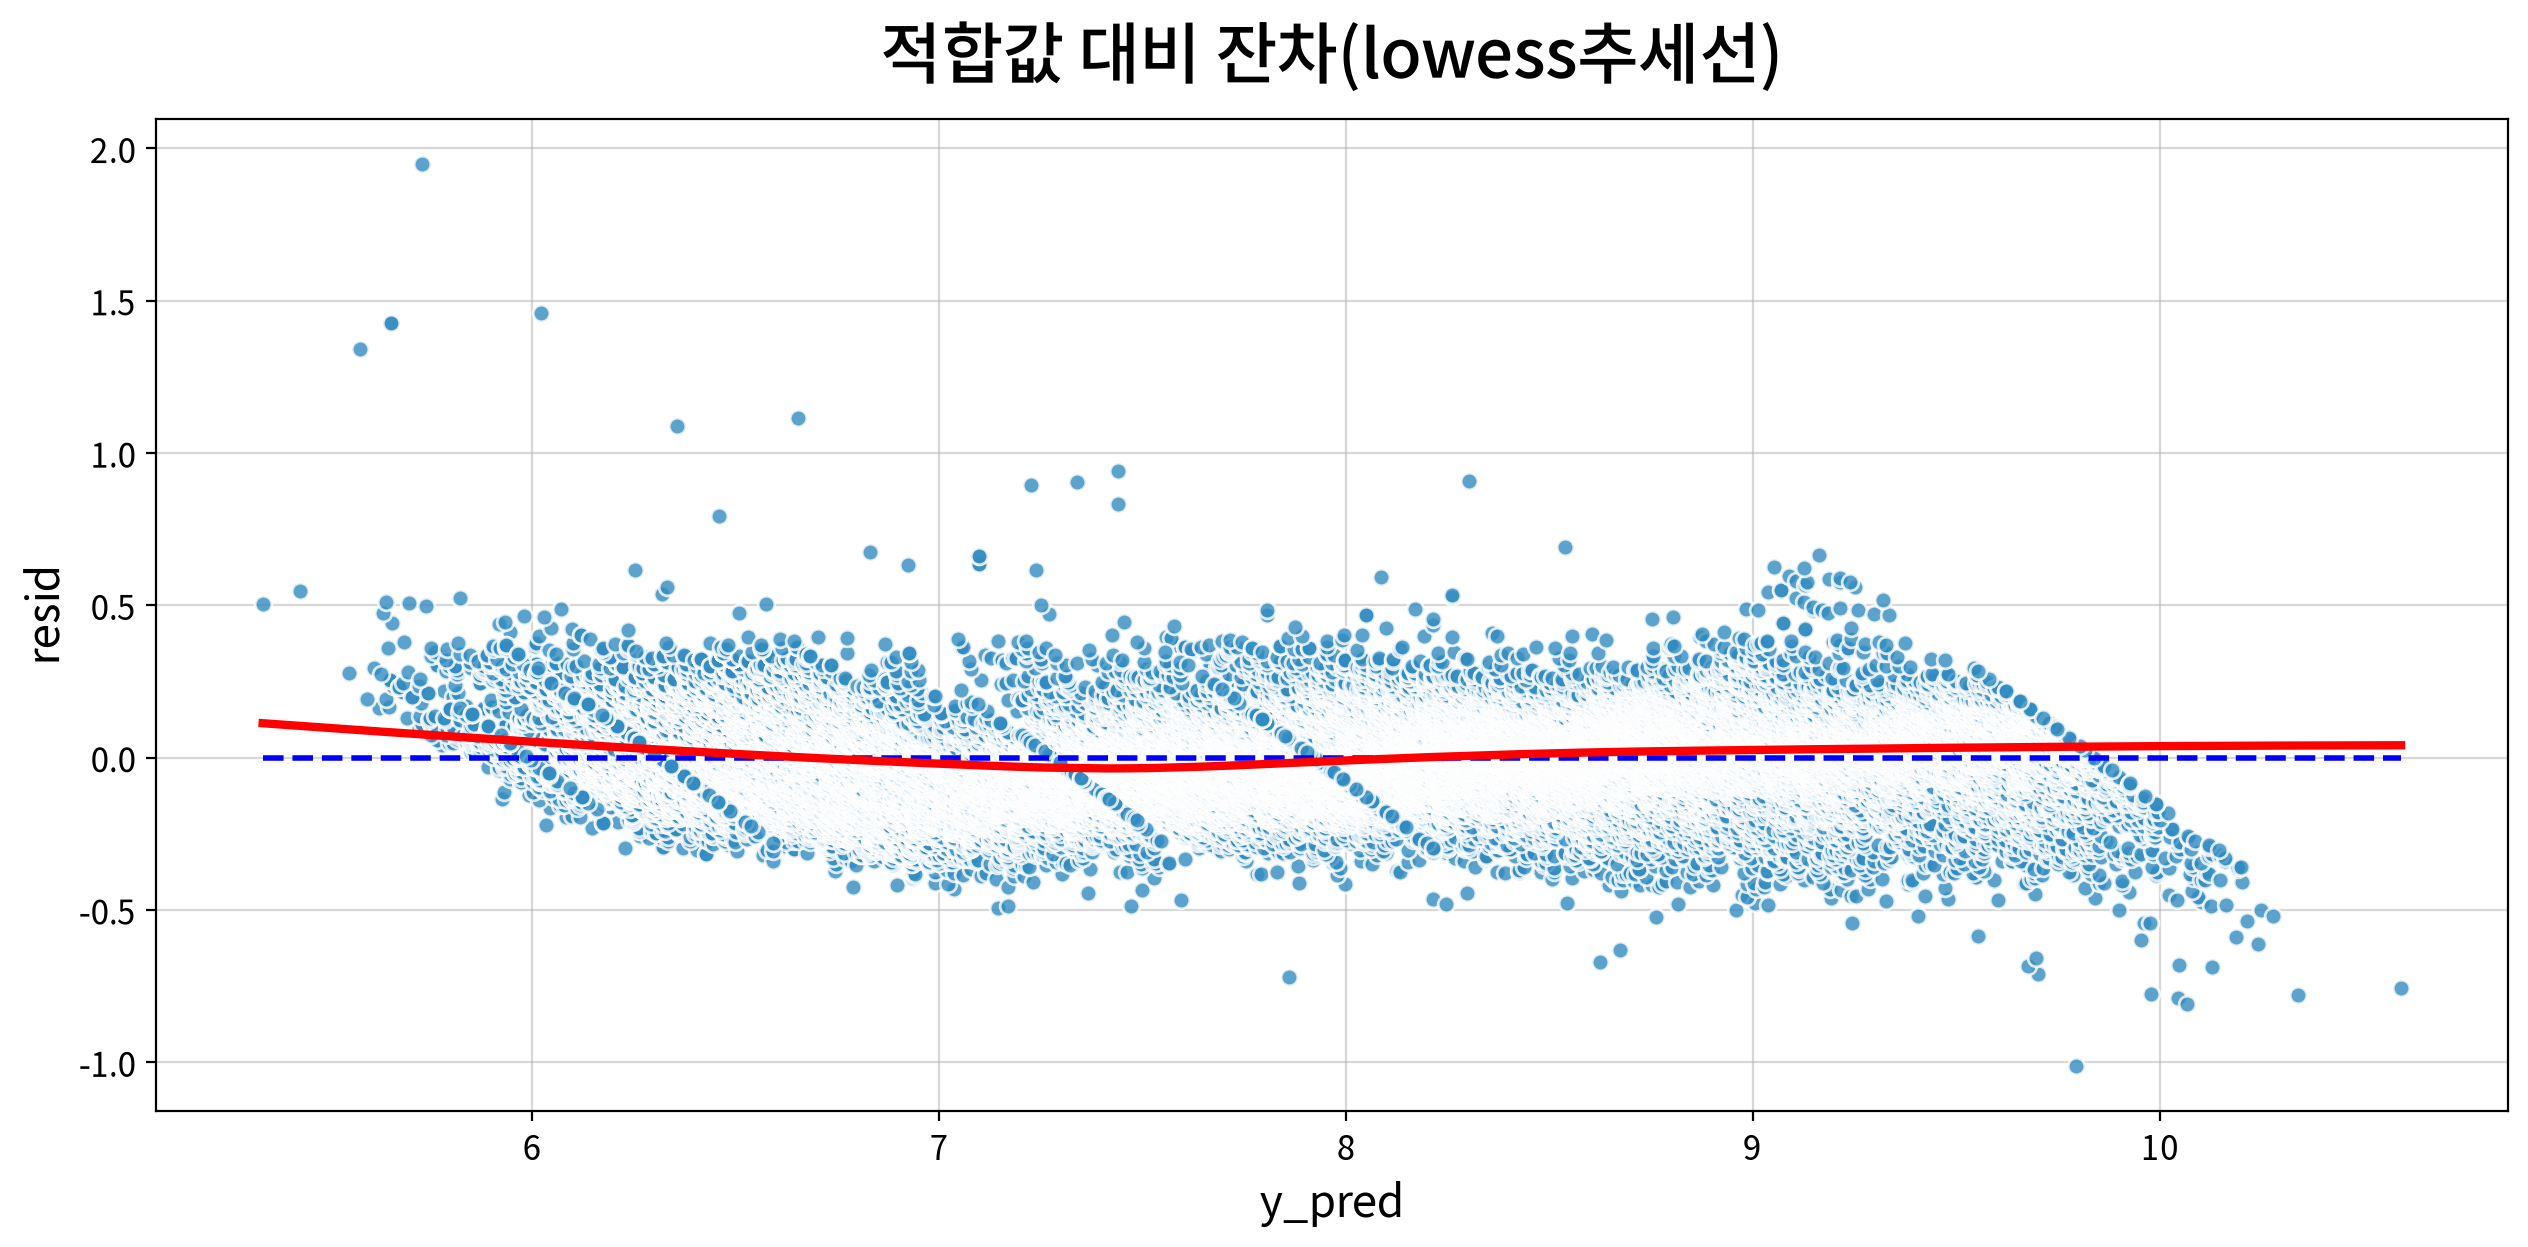

#### 2) 정규성 검정

,statistic,p-value,normality,result
kolmogorov-Smirnov,0.018,0.000,False,대립가설 채택 -> 정규성 위배


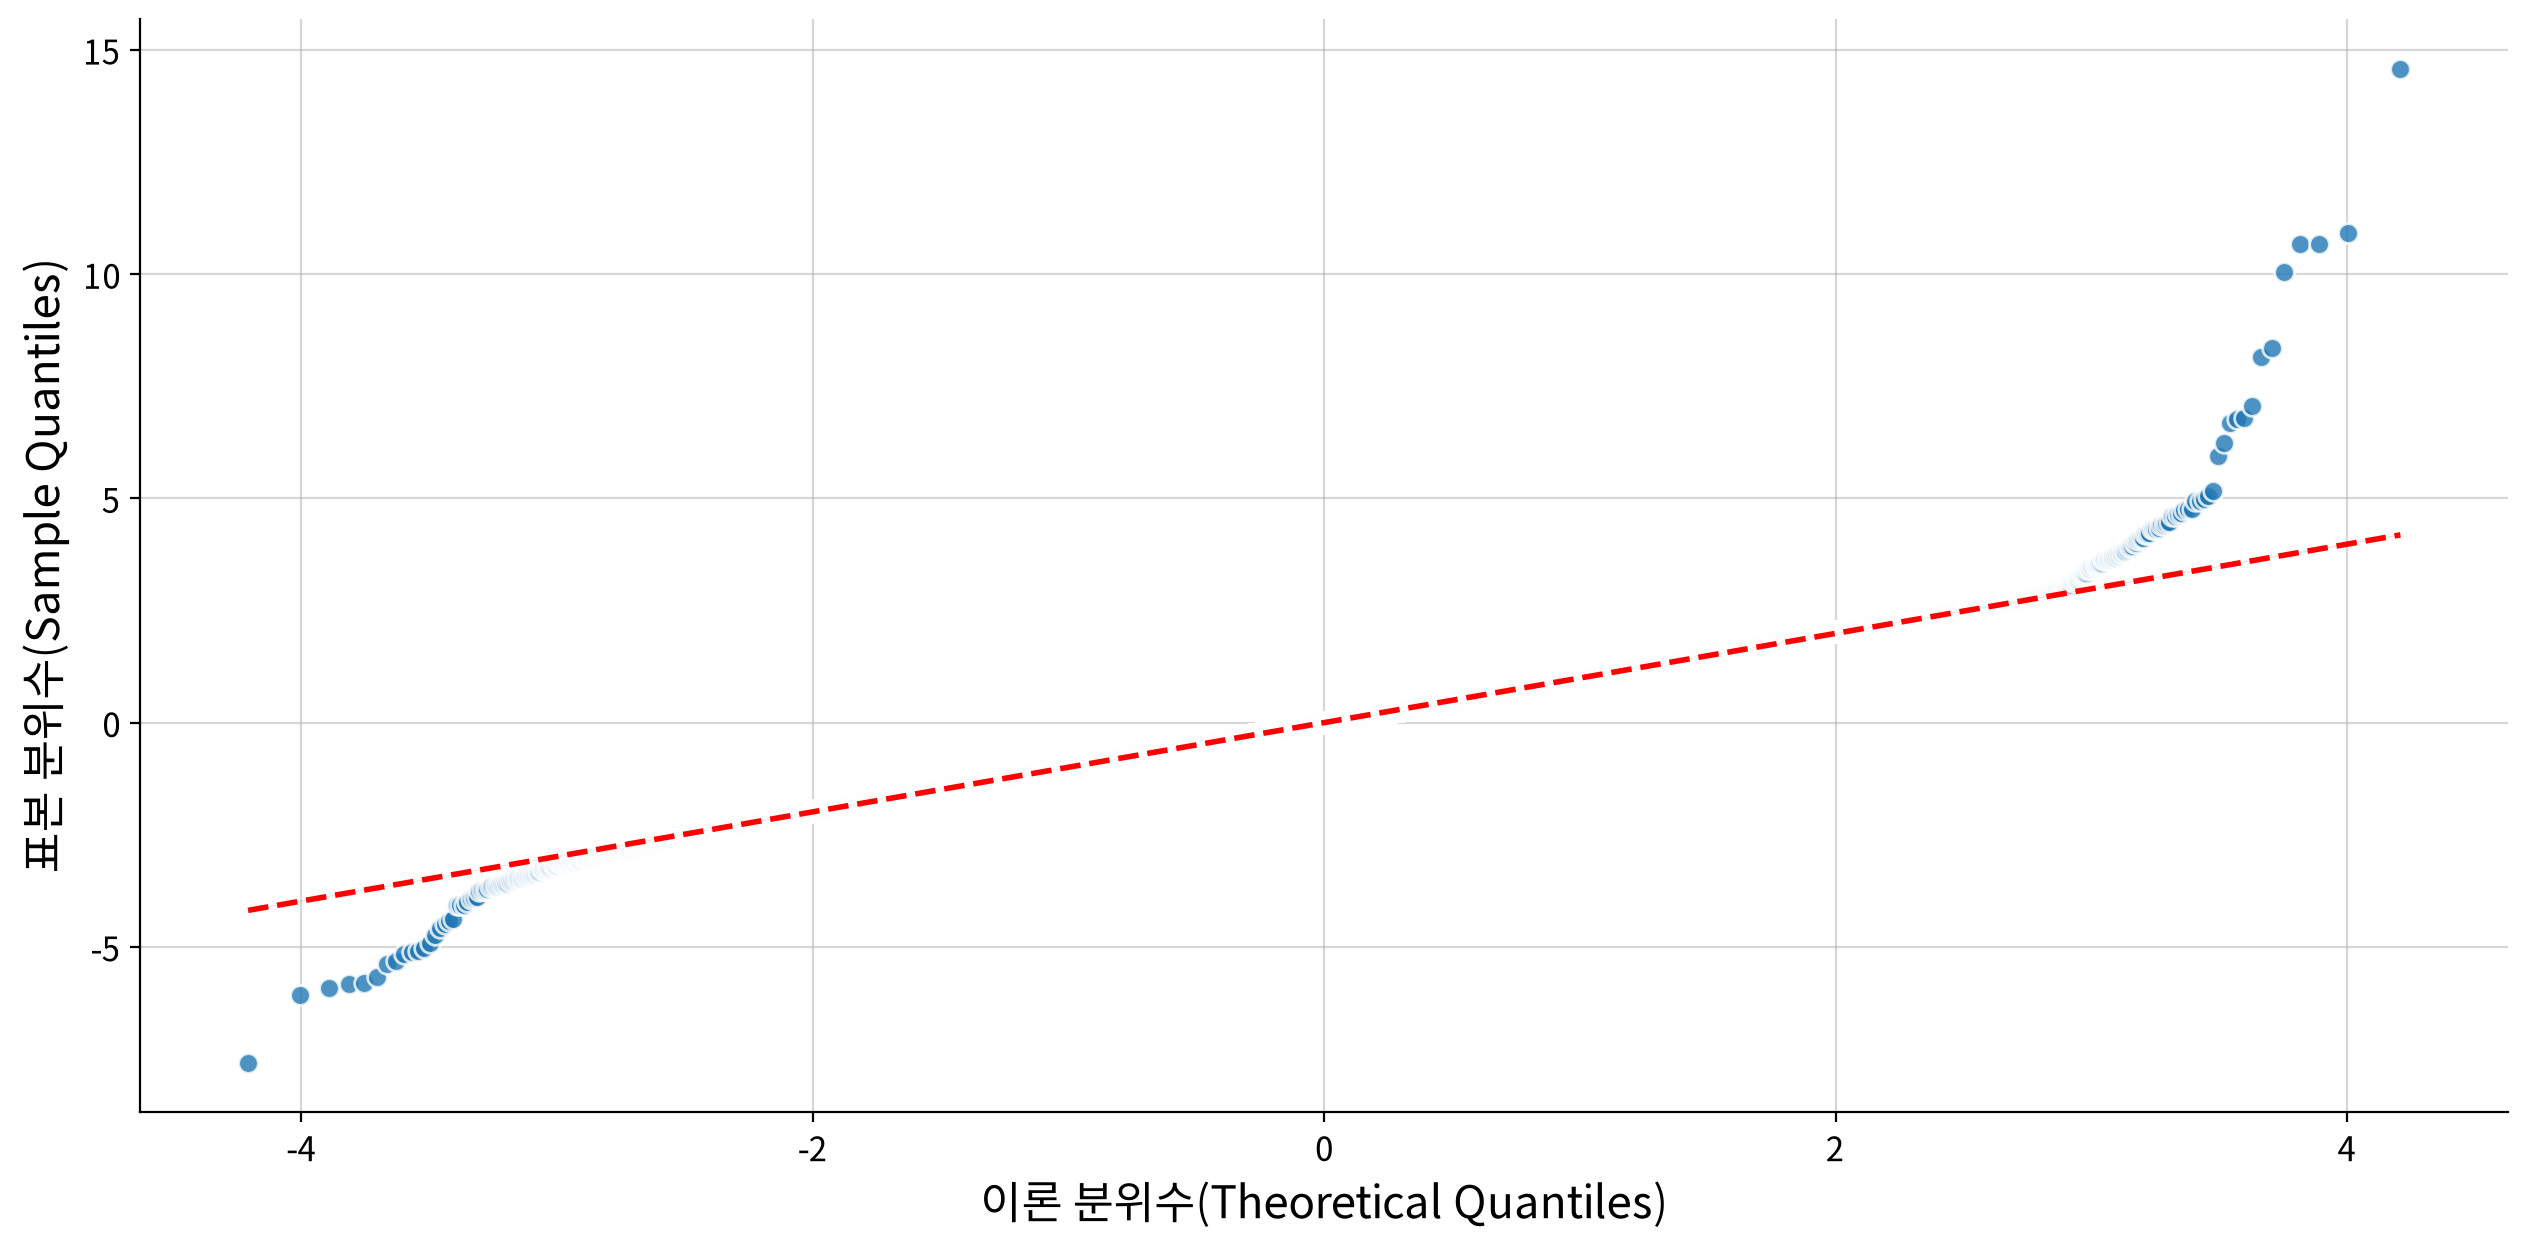

,기대(%),허용범위(%),실제(%),판정
구간,,,,
+-1루트MSE,68.000,68 ~ 68,69.740,위배
+-2루트MSE,95.000,95 ~ 95,95.420,위배
+-3루트MSE,99.700,100 ~ 100,99.600,위배


루트MSE = 0.13 , 구간 규칙 판정: 정규성 위배


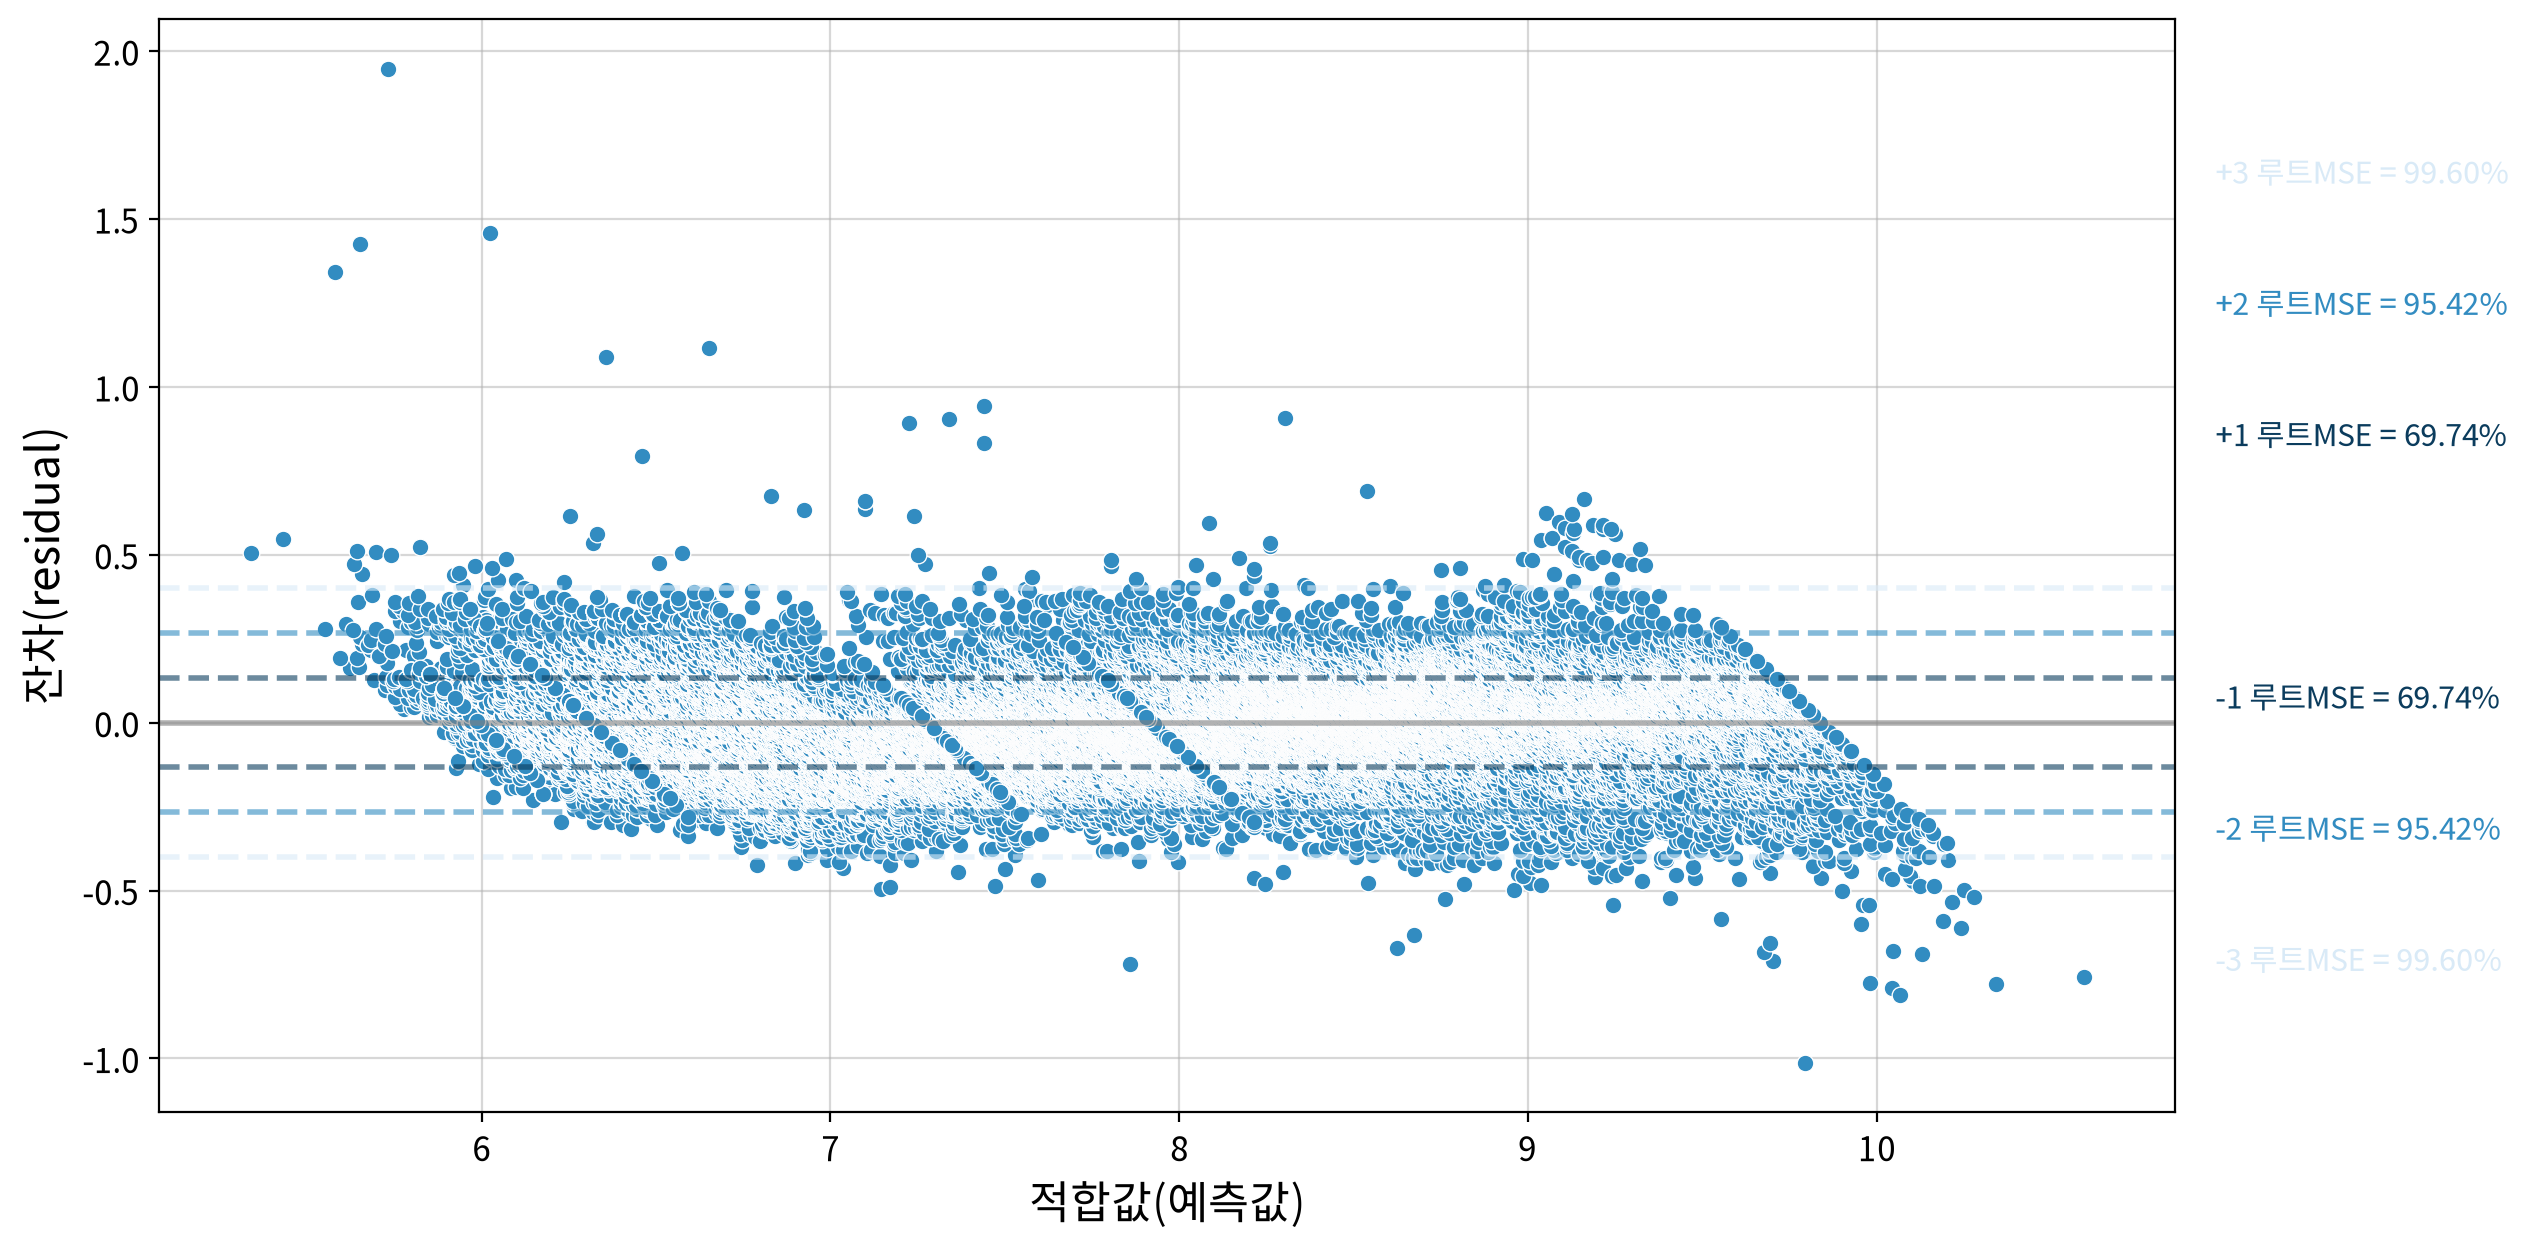

#### 3) 등분산성 검정

,LM statistic,LM p-value,F statistic,F p-value,homoscedasticity,result
Breusch-Pagan,1336.676,0.000,76.125,0.000,False,대립가설 채택 -> 등분산 아님


#### 4) 독립성 검정

,statistic,independence,result
Durbin-Watson,1.253,False,독립성 위반 (양(+)의 자기상관)


In [16]:
my_ols.report_model(final_fit)

In [17]:
# 실무적 기준의 체크 포인트 
checkpoints = {
    "0_기준선": dict(vif=True), 
    "1_로그변환": dict(log=True, vif=True),
    "2_이상치대체": dict(log=True, outlier=True, vif=True)
}

## #연습문제 